# Analyse de l’accessibilité des gares en Île-de-France

Ce notebook analyse l’accessibilité des gares franciliennes à partir des fichiers CSV et GEOJSON fournis.

## 1. Charger et explorer les données CSV

Nous allons importer pandas, charger le fichier CSV, et afficher les premières lignes pour comprendre la structure des données.

In [1]:
import pandas as pd

# Charger le fichier CSV (séparateur ;)
df = pd.read_csv('../data/raw/accessibilite-en-gare.csv', sep=';')

# Afficher les premières lignes et les infos générales
df.head()

,stop_point_id,accessibility_level_id,accessibility_level_name,commentaire,stop_name,stop_point_geopoint
0,stop_point:IDFM:monomodalStopPlace:46387,1,gare ou arrêt non accessible,NaN,Ablon,"48.72578126379895, 2.4198671478914595"
1,stop_point:IDFM:monomodalStopPlace:473364,3,train accessible sur réservation préalable aup...,NaN,Aéroport Charles de Gaulle 2 (Terminal 2),"49.0041455478504, 2.5709800477570233"
2,stop_point:IDFM:monomodalStopPlace:47917,1,gare ou arrêt non accessible,NaN,Angerville,"48.311605620382146, 2.0037505317720075"
3,stop_point:IDFM:monomodalStopPlace:45873,4,train accessible sur demande auprès d'un agent...,NaN,Auber,"48.872348840718196, 2.3296591495793595"
4,stop_point:IDFM:monomodalStopPlace:43070,1,gare ou arrêt non accessible,NaN,Aubergenville Élisabethville,"48.97233225408568, 1.8489603900783327"


In [2]:
# Afficher les informations générales du DataFrame
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 459 entries, 0 to 458
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   stop_point_id             459 non-null    str  
 1   accessibility_level_id    459 non-null    int64
 2   accessibility_level_name  459 non-null    str  
 3   commentaire               17 non-null     str  
 4   stop_name                 459 non-null    str  
 5   stop_point_geopoint       459 non-null    str  
dtypes: int64(1), str(5)
memory usage: 21.6 KB


## 2. Nettoyer et préparer les données

Nous allons séparer la colonne des coordonnées en latitude et longitude, convertir en float, et vérifier les valeurs manquantes.

In [3]:
# Séparer la colonne 'stop_point_geopoint' en 'lat' et 'lon'
df[['lat', 'lon']] = df['stop_point_geopoint'].str.split(',', expand=True)

df['lat'] = df['lat'].astype(float)
df['lon'] = df['lon'].astype(float)

df[['lat', 'lon']].head()

,lat,lon
0,48.725781,2.419867
1,49.004146,2.570980
2,48.311606,2.003751
3,48.872349,2.329659
4,48.972332,1.848960


In [4]:
# Vérifier les valeurs manquantes
df.isnull().sum()

stop_point_id                 0
accessibility_level_id        0
accessibility_level_name      0
commentaire                 442
stop_name                     0
stop_point_geopoint           0
lat                           0
lon                           0
dtype: int64

In [5]:
# Sauvegarder le DataFrame nettoyé pour usage ultérieur
df.to_csv('../data/processed/cleaned_data.csv', index=False)

## 3. Analyser la répartition de l’accessibilité

Comptons le nombre de gares par niveau d’accessibilité.

In [6]:
# Répartition des niveaux d’accessibilité
df['accessibility_level_name'].value_counts()

accessibility_level_name
gare ou arrêt non accessible                                                 213
train accessible sur réservation préalable auprès du service AssistenGare    174
train accessible sur demande auprès d'un agent en station                     58
véhicule accessible en toute autonomie                                        14
Name: count, dtype: int64

## 4. Calculer les pourcentages d’accessibilité

Calculons le pourcentage de chaque niveau d’accessibilité.

In [7]:
# Pourcentage de chaque niveau d’accessibilité
df['accessibility_level_name'].value_counts(normalize=True) * 100

accessibility_level_name
gare ou arrêt non accessible                                                 46.405229
train accessible sur réservation préalable auprès du service AssistenGare    37.908497
train accessible sur demande auprès d'un agent en station                    12.636166
véhicule accessible en toute autonomie                                        3.050109
Name: proportion, dtype: float64

## 5. Lister les gares non accessibles

Filtrons les gares dont le niveau d’accessibilité est « Non accessible ».

In [8]:
# Gares non accessibles
df_non_access = df[df['accessibility_level_name'] == 'Non accessible']
df_non_access[['stop_name', 'accessibility_level_name', 'lat', 'lon']]

,stop_name,accessibility_level_name,lat,lon


## 6. Identifier les zones problématiques

Analysons la distribution géographique des gares non accessibles, par exemple par ligne ou secteur.

In [9]:
# Exemple : nombre de gares non accessibles par ligne
if 'ligne' in df.columns:
    df_non_access['ligne'].value_counts()
else:
    print("Colonne 'ligne' non disponible dans ce dataset.")

Colonne 'ligne' non disponible dans ce dataset.


## 7. Exporter les données nettoyées pour Power BI

Les données nettoyées sont enregistrées dans le dossier `processed/` pour une utilisation dans Power BI.

In [10]:
# (Déjà fait plus haut) Vérification du fichier exporté
import os
os.path.exists('../data/processed/cleaned_data.csv')

True

## 9. Nombre d’arrêts par ligne

Comptons le nombre total de gares par ligne pour identifier les lignes les plus desservies.

In [11]:
# Nombre total d’arrêts par ligne
if 'ligne' in df.columns:
    arrets_par_ligne = df['ligne'].value_counts()
    display(arrets_par_ligne)
else:
    print("Colonne 'ligne' non disponible dans ce dataset.")

Colonne 'ligne' non disponible dans ce dataset.


## 10. Top lignes les plus desservies

Affichons les 5 lignes ayant le plus grand nombre de gares.

In [12]:
# Top 5 des lignes les plus desservies
if 'ligne' in df.columns:
    top_lignes = arrets_par_ligne.head(5)
    display(top_lignes)
else:
    print("Colonne 'ligne' non disponible dans ce dataset.")

Colonne 'ligne' non disponible dans ce dataset.


## 11. Zones mal couvertes

Identifions les zones géographiques avec peu ou pas de gares accessibles (analyse simple par quadrillage).

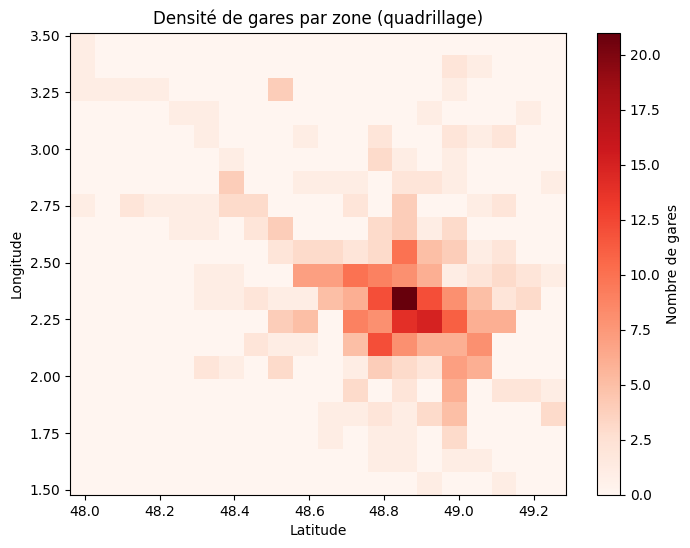

In [13]:
# Quadrillage simple pour repérer les zones mal couvertes
import numpy as np
import matplotlib.pyplot as plt

if 'lat' in df.columns and 'lon' in df.columns:
    # Définir les bornes de la carte
    lat_min, lat_max = df['lat'].min(), df['lat'].max()
    lon_min, lon_max = df['lon'].min(), df['lon'].max()
    
    # Créer une grille
    n_bins = 20
    grid, xedges, yedges = np.histogram2d(df['lat'], df['lon'], bins=n_bins)
    
    # Afficher la densité de gares
    plt.figure(figsize=(8, 6))
    plt.imshow(grid.T, origin='lower', extent=[lat_min, lat_max, lon_min, lon_max], aspect='auto', cmap='Reds')
    plt.colorbar(label='Nombre de gares')
    plt.title('Densité de gares par zone (quadrillage)')
    plt.xlabel('Latitude')
    plt.ylabel('Longitude')
    plt.show()
else:
    print("Colonnes 'lat' et 'lon' non disponibles dans ce dataset.")